# 07 — Distance, Buffer & Concentric-Ring Analysis
## Mueang Phitsanulok Centroid → 20–200 km → Village Counts

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate  
**ข้อมูล:** Thailand Village Points + ADM2 Districts  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · Shapely · xyzservices

Notebook นี้ต่อจาก Notebook 06 โดยเปลี่ยนคำถามจาก

> “Village point อยู่ใน polygon ไหน?”

เป็น

> “Village point อยู่ห่างจากจุดอ้างอิงเท่าไร และจำนวนจุดเปลี่ยนอย่างไรเมื่อระยะทางเพิ่มขึ้น?”

แกนของบท:

$$
\boxed{
Center
\rightarrow
Distance
\rightarrow
Buffer
\rightarrow
Concentric\ Rings
\rightarrow
Count
\rightarrow
Cumulative\ Pattern
}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบายความต่างระหว่าง centroid และ representative point
2. ใช้ projected CRS เพื่อคำนวณระยะทางเป็นเมตร/กิโลเมตร
3. คำนวณ Euclidean distance จากจุดอ้างอิงไปยัง village points
4. หา village points ที่ใกล้จุดอ้างอิงที่สุด
5. สร้าง cumulative buffers ทุก 20 km ตั้งแต่ 20–200 km
6. อธิบายความต่างระหว่าง Buffer และ Ring
7. สร้าง concentric rings แบบ 0–20, 20–40, …, 180–200 km
8. นับ village points แบบ cumulative และแบบราย ring
9. เปรียบเทียบวิธี numeric distance กับ spatial join
10. อธิบายว่าทำไม raw ring count ยังไม่ใช่ density
11. สร้าง static maps, graphs และ interactive Folium map
12. Export buffers, rings, village subset, tables และ HTML

## Recap จาก Notebook 06

Notebook 06 สอนว่า

$$
Point
\rightarrow
Spatial\ Join
\rightarrow
Administrative\ Unit
\rightarrow
Aggregation
\rightarrow
Density
$$

Notebook 07 เพิ่มความสัมพันธ์เชิงระยะทาง:

$$
\boxed{
Point_i
\rightarrow
Distance\ from\ Origin
}
$$

และเปลี่ยน study area จาก “ขอบเขตการปกครอง” เป็น “ระยะทางจากจุดอ้างอิง”

## หมายเหตุจาก schema จริงของ TH_VILLAGE2012

Notebook 06 แสดงว่า fields ที่ควรใช้เชิงความหมายคือ

```text
NAME      → ชื่อหมู่บ้าน
TAM_NAME  → ชื่อตำบล
AMP_NAME  → ชื่ออำเภอ
PRV_NAME  → ชื่อจังหวัด
```

ดังนั้น Notebook 07 จะใช้ fields เหล่านี้โดยตรง ถ้ามีอยู่จริง

> **Field name ต้องตรวจด้วย sample values ไม่ใช่เดาจากชื่อเพียงอย่างเดียว**

## Temporal consistency

Village dataset เป็นชุดปี 2012 ขณะที่ administrative boundaries ที่ใช้ในชุดการสอนอาจมาจากปีใหม่กว่า

ดังนั้น Notebook นี้เหมาะสำหรับ **การเรียนวิธีวิเคราะห์เชิงพื้นที่** แต่ไม่ควรตีความเป็นฐานข้อมูลการตั้งถิ่นฐานปัจจุบันโดยไม่ตรวจสอบ temporal consistency

```text
Spatial consistency
+
Temporal consistency
```

ต้องพิจารณาควบคู่กัน

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile
import json

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import folium
import xyzservices.providers as xyz

from folium.plugins import FastMarkerCluster
from IPython.display import display

print("GeoPandas:", gpd.__version__)
print("Pandas   :", pd.__version__)
print("Folium   :", folium.__version__)

GeoPandas: 1.2.0
Pandas   : 2.2.3
Folium   : 0.20.0


## 2. Font ภาษาไทย — Sarabun

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 3. Workspace

In [4]:
DATA_DIR = Path("/content/gis07_data")
OUTPUT_DIR = Path("/content/gis07_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis07_data
Output folder : /content/gis07_outputs


## 4. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 5. Field helper

In [6]:
def find_column(gdf, candidates, required=False):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None

# Part A — Load Village Points and ADM2

## 6. Download Village Points

In [7]:
VILLAGE_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/village/TH_VILLAGE2012.zip"
)

village_shp = download_and_extract_zip(
    VILLAGE_URL,
    "TH_VILLAGE2012.zip",
    "TH_VILLAGE2012"
)

village = gpd.read_file(
    village_shp,
    encoding="UTF-8"
)

print("Village features:", len(village))
print("CRS:", village.crs)
print("Columns:")
print(list(village.columns))

Shapefile: /content/gis07_data/TH_VILLAGE2012/TH_VILLAGE2012.shp
Village features: 65213
CRS: EPSG:4326
Columns:
['VILL_', 'VILL_ID', 'NAME', 'TYPE', 'ADM_ID', 'AMP_ID', 'PRV_ID', 'TAM_NAME', 'AMP_NAME', 'PRV_NAME', 'MAIN_ID', 'geometry']


## 7. Confirm village schema

In [8]:
NAME_FIELD = find_column(
    village,
    ["NAME", "VILL_NAME", "VILLAGE"],
    required=True
)

TAMBON_FIELD = find_column(
    village,
    ["TAM_NAME", "TAMBON", "ADM3_TH"],
    required=True
)

DISTRICT_FIELD = find_column(
    village,
    ["AMP_NAME", "AMPHOE", "ADM2_TH"],
    required=True
)

PROVINCE_FIELD = find_column(
    village,
    ["PRV_NAME", "PROVINCE", "ADM1_TH"],
    required=True
)

print("Village :", NAME_FIELD)
print("Tambon  :", TAMBON_FIELD)
print("District:", DISTRICT_FIELD)
print("Province:", PROVINCE_FIELD)

display(
    village[
        [
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "geometry"
        ]
    ].head(10)
)

Village : NAME
Tambon  : TAM_NAME
District: AMP_NAME
Province: PRV_NAME


,NAME,TAM_NAME,AMP_NAME,PRV_NAME,geometry
0,บ้านท่าลานเตียน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11985 15.41106)
1,บ้านหนองสะแก,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11425 15.40837)
2,บ้านหัวยาง,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11983 15.40744)
3,บ้านสะพานหิน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10213 15.40663)
4,บ้านทุ่งประพาส,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.09463 15.39853)
5,บ้านหางน้ำหนองแขม,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.14494 15.39737)
6,บ้านหลั่น,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.11045 15.39574)
7,บ้านหางน้ำหนองแขม,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.14024 15.39016)
8,ท่าฉนวน,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10948 15.38761)
9,บ้านทุ่งใหญ่,ท่าฉนวน,มโนรมย์,ชัยนาท,POINT (100.10481 15.38582)


## 8. Download ADM2

In [9]:
ADM2_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm2/tha_admbnda_adm2_shapefile.zip"
)

adm2_shp = download_and_extract_zip(
    ADM2_URL,
    "tha_admbnda_adm2_shapefile.zip",
    "tha_adm2"
)

district = gpd.read_file(
    adm2_shp,
    encoding="UTF-8"
)

print("District features:", len(district))
print("CRS:", district.crs)

Shapefile: /content/gis07_data/tha_adm2/tha_admbnda_adm2.shp
District features: 928
CRS: EPSG:4326


## 9. Detect ADM2 fields

In [10]:
d_adm1_th = find_column(
    district,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

d_adm2_th = find_column(
    district,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

d_adm2_code = find_column(
    district,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

print("Province field:", d_adm1_th)
print("District field:", d_adm2_th)
print("District code :", d_adm2_code)

Province field: ADM1_TH
District field: ADM2_TH
District code : ADM2_PCODE


# Part B — Origin: Mueang Phitsanulok

## 10. Query Mueang Phitsanulok

In [11]:
mueang_phs = district[
    district[d_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
    &
    district[d_adm2_th]
    .astype(str)
    .str.contains(
        "เมืองพิษณุโลก",
        na=False
    )
].copy()

print("Selected features:", len(mueang_phs))

display(
    mueang_phs[
        [
            d_adm2_code,
            d_adm1_th,
            d_adm2_th
        ]
    ]
)

Selected features: 1


,ADM2_PCODE,ADM1_TH,ADM2_TH
683,TH6501,พิษณุโลก,เมืองพิษณุโลก


ถ้า query ได้มากกว่า 1 feature ให้ตรวจ schema และชื่ออำเภอก่อนวิเคราะห์ต่อ

In [12]:
if len(mueang_phs) != 1:
    raise ValueError(
        "คาดว่าจะพบ Mueang Phitsanulok 1 feature "
        f"แต่พบ {len(mueang_phs)}"
    )

## 11. Reproject เป็น EPSG:32647

In [13]:
mueang_utm = mueang_phs.to_crs(
    "EPSG:32647"
)

print("Analysis CRS:", mueang_utm.crs)

Analysis CRS: EPSG:32647


## 12. Centroid vs Representative Point

### Centroid

เป็น geometric center ของ polygon

$$
C=(x_c,y_c)
$$

### Representative point

เป็นจุดที่รับประกันว่าอยู่ภายใน polygon

```text
centroid
→ geometric center

representative_point()
→ guaranteed inside polygon
```

> Geometric centroid ไม่จำเป็นต้องเป็นศูนย์กลางเมือง ศาลากลาง หรือศูนย์กลางการเดินทาง

In [14]:
centroid_geom = (
    mueang_utm.geometry
    .centroid
    .iloc[0]
)

repr_geom = (
    mueang_utm.geometry
    .representative_point()
    .iloc[0]
)

center_gdf = gpd.GeoDataFrame(
    {
        "center_type": [
            "Geometric centroid",
            "Representative point"
        ]
    },
    geometry=[
        centroid_geom,
        repr_geom
    ],
    crs="EPSG:32647"
)

display(center_gdf)

,center_type,geometry
0,Geometric centroid,POINT (636875.959 1861999.424)
1,Representative point,POINT (633064.129 1858596.121)


## 13. Distance between centroid and representative point

In [15]:
center_difference_km = (
    centroid_geom.distance(
        repr_geom
    )
    / 1000
)

print(
    f"Centroid ↔ representative point: "
    f"{center_difference_km:.3f} km"
)

Centroid ↔ representative point: 5.110 km


## 14. Map both center candidates

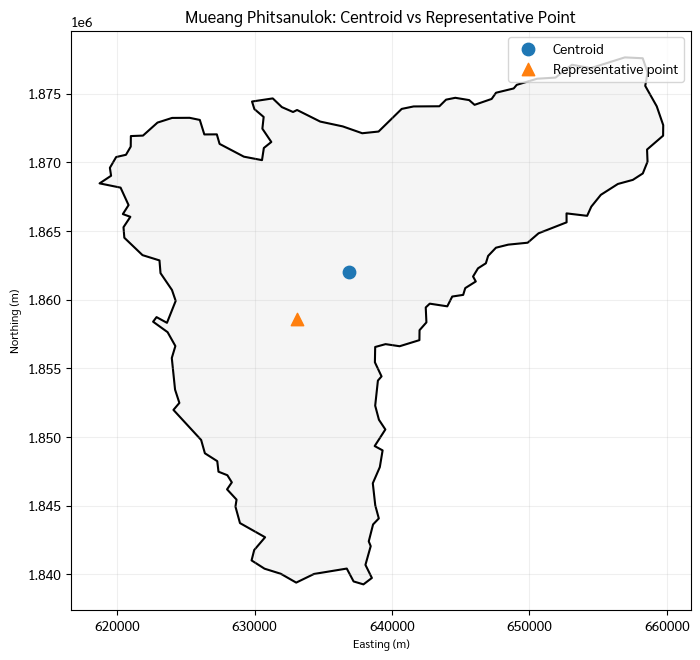

In [16]:
fig_center, ax = plt.subplots(
    figsize=(8, 8)
)

mueang_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=1.5
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=80,
    marker="o",
    label="Centroid"
)

gpd.GeoSeries(
    [repr_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=80,
    marker="^",
    label="Representative point"
)

ax.set_title(
    "Mueang Phitsanulok: Centroid vs Representative Point"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

Notebook นี้จะใช้ **geometric centroid** เป็น origin เพื่อให้วิธี reproducible จาก polygon geometry

$$
oxed{
Geometric\ centroid

eq
Urban\ center
}
$$

# Part C — Distance from the Origin

## 15. Euclidean distance

ใน projected CRS ที่ใช้หน่วย meter:

$$
d_i=
\sqrt{
(x_i-x_c)^2+
(y_i-y_c)^2
}
$$

แล้วแปลงเป็นกิโลเมตร:

$$
d_{km}=
\frac{d_m}{1000}
$$

## 16. Reproject village points to EPSG:32647

In [17]:
village_utm = village.to_crs(
    "EPSG:32647"
)

print("Village CRS:", village_utm.crs)
print("Village features:", len(village_utm))

Village CRS: EPSG:32647
Village features: 65213


## 17. Calculate distance_km

In [18]:
village_utm["distance_km"] = (
    village_utm.geometry.distance(
        centroid_geom
    )
    / 1000
)

display(
    village_utm[
        [
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "distance_km"
        ]
    ]
    .sort_values("distance_km")
    .head(10)
    .round({"distance_km": 3})
)

,NAME,TAM_NAME,AMP_NAME,PRV_NAME,distance_km
22893,บ้านคลองมหาดไทย,อรัญญิก,เมือง,พิษณุโลก,1.014
22904,บ้านหนองปลาค้าว,อรัญญิก,เมือง,พิษณุโลก,1.052
22865,บ้านเต็งหนาม,หัวรอ,เมือง,พิษณุโลก,2.105
22872,บ้านตาปะขาว,หัวรอ,เมือง,พิษณุโลก,2.273
22897,บ้านในค่าย (คลองบางสะแก),วัดจันทร์,เมือง,พิษณุโลก,2.925
22868,บ้านตาปะขาวหาย,หัวรอ,เมือง,พิษณุโลก,3.256
22939,บ้านโคกมะตูม,อรัญญิก,เมือง,พิษณุโลก,3.486
22943,บ้านคลองจันทร์,อรัญญิก,เมือง,พิษณุโลก,3.841
22864,บ้านตาลสุวรรณ,ดอนทอง,เมือง,พิษณุโลก,3.936
22892,บ้านบางสะแก,บ้านคลอง,เมือง,พิษณุโลก,4.011


## 18. Ten nearest village points

In [19]:
nearest10 = (
    village_utm
    .nsmallest(
        10,
        "distance_km"
    )
    .copy()
)

nearest10["rank"] = range(
    1,
    len(nearest10) + 1
)

display(
    nearest10[
        [
            "rank",
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "distance_km"
        ]
    ].round({"distance_km": 3})
)

,rank,NAME,TAM_NAME,AMP_NAME,PRV_NAME,distance_km
22893,1,บ้านคลองมหาดไทย,อรัญญิก,เมือง,พิษณุโลก,1.014
22904,2,บ้านหนองปลาค้าว,อรัญญิก,เมือง,พิษณุโลก,1.052
22865,3,บ้านเต็งหนาม,หัวรอ,เมือง,พิษณุโลก,2.105
22872,4,บ้านตาปะขาว,หัวรอ,เมือง,พิษณุโลก,2.273
22897,5,บ้านในค่าย (คลองบางสะแก),วัดจันทร์,เมือง,พิษณุโลก,2.925
22868,6,บ้านตาปะขาวหาย,หัวรอ,เมือง,พิษณุโลก,3.256
22939,7,บ้านโคกมะตูม,อรัญญิก,เมือง,พิษณุโลก,3.486
22943,8,บ้านคลองจันทร์,อรัญญิก,เมือง,พิษณุโลก,3.841
22864,9,บ้านตาลสุวรรณ,ดอนทอง,เมือง,พิษณุโลก,3.936
22892,10,บ้านบางสะแก,บ้านคลอง,เมือง,พิษณุโลก,4.011


ข้อควรระวัง:

\[
oxed{
Euclidean\ distance

eq
Road\ distance

eq
Travel\ time
}
\]

ระยะ 20 km ในบทนี้คือระยะเส้นตรงบน projected plane ไม่ใช่ระยะขับรถ

# Part D — Cumulative Buffers

## 19. Buffer concept

Buffer รอบจุด $C$ ที่รัศมี $r$ คือ

$$
B(C,r)=
\{P:d(P,C)\le r\}
$$

เราจะสร้างรัศมี

```text
20, 40, 60, ..., 200 km
```

In [20]:
radii_km = list(
    range(
        20,
        201,
        20
    )
)

print(radii_km)

[20, 40, 60, 80, 100, 120, 140, 160, 180, 200]


## 20. Create cumulative buffers

In [21]:
buffer_rows = []

for r_km in radii_km:
    buffer_rows.append({
        "radius_km": r_km,
        "geometry": centroid_geom.buffer(
            r_km * 1000
        )
    })

buffers = gpd.GeoDataFrame(
    buffer_rows,
    geometry="geometry",
    crs="EPSG:32647"
)

display(buffers)

,radius_km,geometry
0,20,"POLYGON ((656875.959 1861999.424, 656779.653 1..."
1,40,"POLYGON ((676875.959 1861999.424, 676683.348 1..."
2,60,"POLYGON ((696875.959 1861999.424, 696587.042 1..."
3,80,"POLYGON ((716875.959 1861999.424, 716490.737 1..."
4,100,"POLYGON ((736875.959 1861999.424, 736394.431 1..."
5,120,"POLYGON ((756875.959 1861999.424, 756298.126 1..."
6,140,"POLYGON ((776875.959 1861999.424, 776201.82 18..."
7,160,"POLYGON ((796875.959 1861999.424, 796105.515 1..."
8,180,"POLYGON ((816875.959 1861999.424, 816009.21 18..."
9,200,"POLYGON ((836875.959 1861999.424, 835912.904 1..."


Buffers เป็น nested zones:

$$
B_{20}
\subset
B_{40}
\subset
B_{60}
\subset
...
\subset
B_{200}
$$

## 21. Buffer-outline map

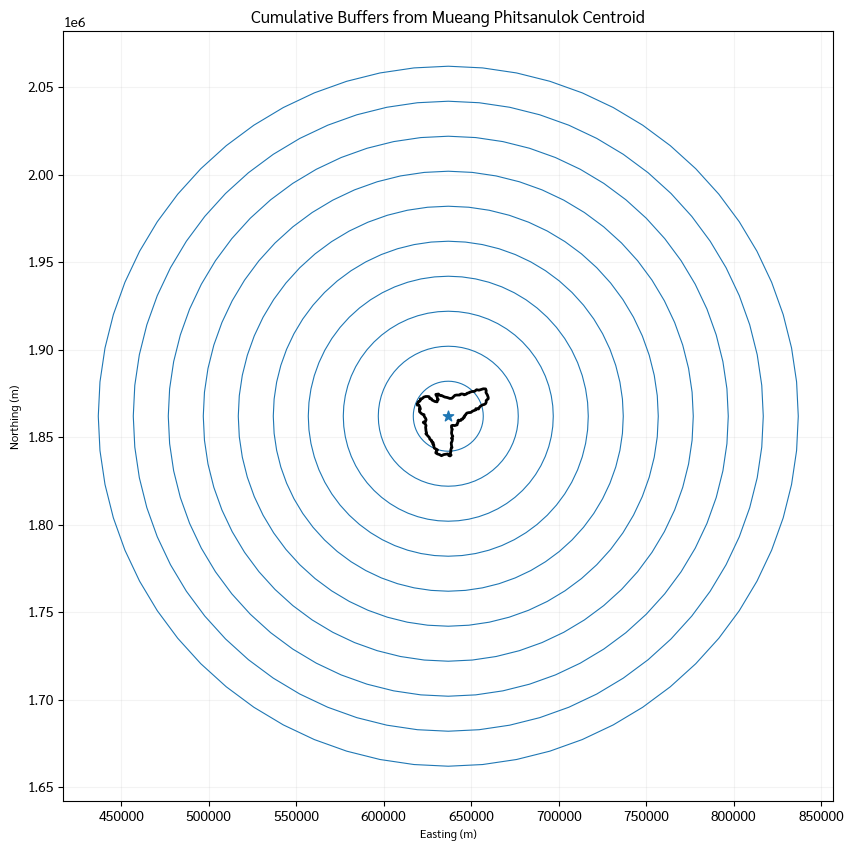

In [22]:
fig_buffers, ax = plt.subplots(
    figsize=(10, 10)
)

buffers.boundary.plot(
    ax=ax,
    linewidth=0.8
)

mueang_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=60,
    marker="*"
)

ax.set_title(
    "Cumulative Buffers from Mueang Phitsanulok Centroid"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

plt.show()

# Part E — Cumulative Village Count

## 22. Cumulative count

จำนวน village points ภายในระยะ $r$:

$$
N(\le r)
=
\sum_i
I(d_i\le r)
$$

In [23]:
cumulative_rows = []

for r_km in radii_km:
    n = int(
        (
            village_utm[
                "distance_km"
            ]
            <= r_km
        ).sum()
    )

    cumulative_rows.append({
        "radius_km": r_km,
        "village_count": n
    })

cumulative_df = pd.DataFrame(
    cumulative_rows
)

display(cumulative_df)

,radius_km,village_count
0,20,227
1,40,695
2,60,1407
3,80,2358
4,100,3763
5,120,5103
6,140,6221
7,160,7539
8,180,9082
9,200,10667


## 23. Cumulative percentage

In [24]:
n_200 = int(
    cumulative_df.loc[
        cumulative_df[
            "radius_km"
        ] == 200,
        "village_count"
    ].iloc[0]
)

cumulative_df[
    "cumulative_pct_of_200km"
] = (
    100
    * cumulative_df[
        "village_count"
    ]
    / n_200
)

display(
    cumulative_df.round(2)
)

,radius_km,village_count,cumulative_pct_of_200km
0,20,227,2.13
1,40,695,6.52
2,60,1407,13.19
3,80,2358,22.11
4,100,3763,35.28
5,120,5103,47.84
6,140,6221,58.32
7,160,7539,70.68
8,180,9082,85.14
9,200,10667,100.00


$$
P(\le r)
=
\frac{
N(\le r)
}{
N(\le200)
}
\times100
$$

ค่า 100% ในตารางนี้หมายถึง village points ทั้งหมดที่อยู่ภายใน **200 km study radius** ไม่ใช่หมู่บ้านทั้งหมดของประเทศไทย

## 24. Cumulative-count curve

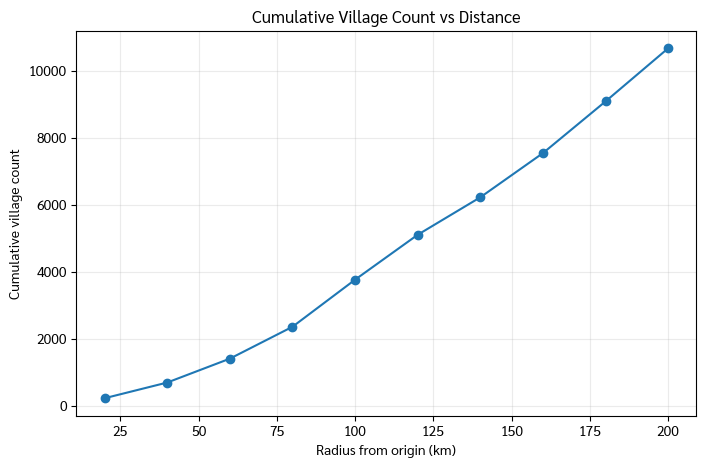

In [25]:
fig_cumulative, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    cumulative_df["radius_km"],
    cumulative_df["village_count"],
    marker="o"
)

ax.set_title(
    "Cumulative Village Count vs Distance"
)
ax.set_xlabel(
    "Radius from origin (km)"
)
ax.set_ylabel(
    "Cumulative village count"
)
ax.grid(alpha=0.25)

plt.show()

## 25. Cumulative-percentage curve

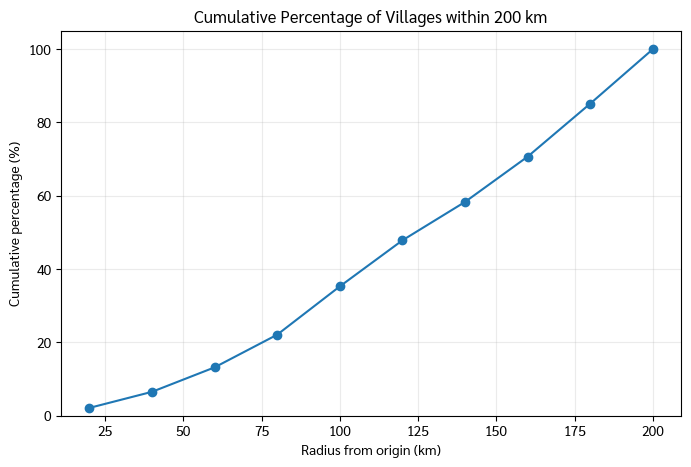

In [26]:
fig_cumulative_pct, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    cumulative_df["radius_km"],
    cumulative_df[
        "cumulative_pct_of_200km"
    ],
    marker="o"
)

ax.set_title(
    "Cumulative Percentage of Villages within 200 km"
)
ax.set_xlabel(
    "Radius from origin (km)"
)
ax.set_ylabel(
    "Cumulative percentage (%)"
)
ax.set_ylim(0, 105)
ax.grid(alpha=0.25)

plt.show()

# Part F — Concentric Rings

## 26. Buffer ≠ Ring

### Buffer 40 km

รวมทุกพื้นที่ตั้งแต่ 0–40 km

### Ring 20–40 km

รวมเฉพาะพื้นที่ระหว่าง 20 กับ 40 km

ดังนั้น

$$
\boxed{
Buffer \neq Ring
}
$$

Ring $j$:

$$
R_j=
B(r_j)-B(r_{j-1})
$$

## 27. Create ring polygons

In [27]:
ring_rows = []

inner_km = 0

for outer_km in radii_km:
    outer_geom = centroid_geom.buffer(
        outer_km * 1000
    )

    if inner_km == 0:
        ring_geom = outer_geom
    else:
        inner_geom = centroid_geom.buffer(
            inner_km * 1000
        )

        ring_geom = outer_geom.difference(
            inner_geom
        )

    ring_rows.append({
        "ring_from_km": inner_km,
        "ring_to_km": outer_km,
        "ring_label": (
            f"{inner_km}–{outer_km} km"
        ),
        "geometry": ring_geom
    })

    inner_km = outer_km

rings = gpd.GeoDataFrame(
    ring_rows,
    geometry="geometry",
    crs="EPSG:32647"
)

display(
    rings[
        [
            "ring_from_km",
            "ring_to_km",
            "ring_label"
        ]
    ]
)

,ring_from_km,ring_to_km,ring_label
0,0,20,0–20 km
1,20,40,20–40 km
2,40,60,40–60 km
3,60,80,60–80 km
4,80,100,80–100 km
5,100,120,100–120 km
6,120,140,120–140 km
7,140,160,140–160 km
8,160,180,160–180 km
9,180,200,180–200 km


## 28. Classify village points by numeric distance

In [28]:
bins = [
    0,
    20,
    40,
    60,
    80,
    100,
    120,
    140,
    160,
    180,
    200
]

labels = [
    f"{bins[i]}–{bins[i+1]} km"
    for i in range(
        len(bins) - 1
    )
]

village_200 = village_utm[
    village_utm[
        "distance_km"
    ] <= 200
].copy()

village_200[
    "distance_ring"
] = pd.cut(
    village_200[
        "distance_km"
    ],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

print(
    "All Thailand village points:",
    len(village_utm)
)

print(
    "Village points within 200 km:",
    len(village_200)
)

All Thailand village points: 65213
Village points within 200 km: 10667


## 29. Count villages by ring — numeric method

In [29]:
ring_count_numeric = (
    village_200[
        "distance_ring"
    ]
    .value_counts(
        sort=False
    )
    .rename_axis(
        "ring_label"
    )
    .reset_index(
        name="village_count_numeric"
    )
)

display(
    ring_count_numeric
)

,ring_label,village_count_numeric
0,0–20 km,227
1,20–40 km,468
2,40–60 km,712
3,60–80 km,951
4,80–100 km,1405
5,100–120 km,1340
6,120–140 km,1118
7,140–160 km,1318
8,160–180 km,1543
9,180–200 km,1585


จำนวนเฉพาะแต่ละ ring:

$$
N_j=
\sum_i
I(
r_{j-1}<d_i\le r_j
)
$$

## 30. Ring-count bar chart

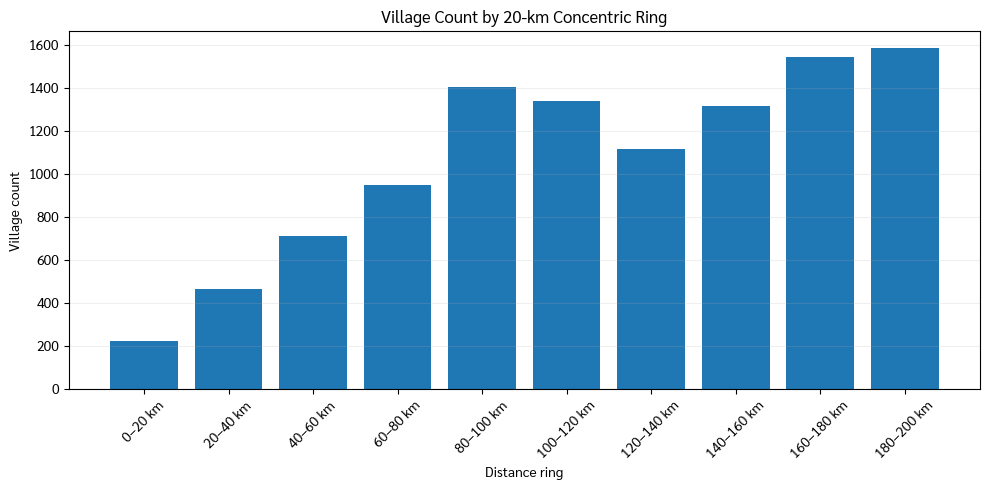

In [30]:
fig_ring_count, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    ring_count_numeric[
        "ring_label"
    ].astype(str),
    ring_count_numeric[
        "village_count_numeric"
    ]
)

ax.set_title(
    "Village Count by 20-km Concentric Ring"
)
ax.set_xlabel(
    "Distance ring"
)
ax.set_ylabel(
    "Village count"
)
ax.tick_params(
    axis="x",
    rotation=45
)
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

# Part G — Numeric Method vs Spatial Method

## 31. Spatial Join: Village → Ring

หลังจากจัดกลุ่มด้วย `pd.cut()` แล้ว เราจะตรวจอีกครั้งด้วย GIS geometry

```text
Village point
within
Ring polygon
```

In [31]:
rings_for_join = rings[
    [
        "ring_from_km",
        "ring_to_km",
        "ring_label",
        "geometry"
    ]
].copy()

village_ring_join = gpd.sjoin(
    village_200[
        [
            NAME_FIELD,
            TAMBON_FIELD,
            DISTRICT_FIELD,
            PROVINCE_FIELD,
            "distance_km",
            "distance_ring",
            "geometry"
        ]
    ],
    rings_for_join,
    how="left",
    predicate="within"
)

display(
    village_ring_join[
        [
            NAME_FIELD,
            "distance_km",
            "distance_ring",
            "ring_label"
        ]
    ].head(15)
)

,NAME,distance_km,distance_ring,ring_label
0,บ้านท่าลานเตียน,158.777351,140–160 km,140–160 km
1,บ้านหนองสะแก,159.139834,140–160 km,140–160 km
2,บ้านหัวยาง,159.175137,140–160 km,140–160 km
3,บ้านสะพานหิน,159.485113,140–160 km,140–160 km
4,บ้านทุ่งประพาส,160.473799,160–180 km,160–180 km
5,บ้านหางน้ำหนองแขม,160.010132,160–180 km,160–180 km
6,บ้านหลั่น,160.575229,160–180 km,160–180 km
7,บ้านหางน้ำหนองแขม,160.851410,160–180 km,160–180 km
8,ท่าฉนวน,161.480771,160–180 km,160–180 km
9,บ้านทุ่งใหญ่,161.735394,160–180 km,160–180 km


## 32. Count by spatial join

In [32]:
ring_count_spatial = (
    village_ring_join[
        "ring_label"
    ]
    .value_counts()
    .rename_axis(
        "ring_label"
    )
    .reset_index(
        name="village_count_spatial"
    )
)

ring_compare = (
    rings[
        ["ring_label"]
    ]
    .merge(
        ring_count_numeric,
        on="ring_label",
        how="left"
    )
    .merge(
        ring_count_spatial,
        on="ring_label",
        how="left"
    )
)

ring_compare[
    [
        "village_count_numeric",
        "village_count_spatial"
    ]
] = (
    ring_compare[
        [
            "village_count_numeric",
            "village_count_spatial"
        ]
    ]
    .fillna(0)
    .astype(int)
)

ring_compare[
    "difference"
] = (
    ring_compare[
        "village_count_numeric"
    ]
    -
    ring_compare[
        "village_count_spatial"
    ]
)

display(ring_compare)

,ring_label,village_count_numeric,village_count_spatial,difference
0,0–20 km,227,226,1
1,20–40 km,468,468,0
2,40–60 km,712,710,2
3,60–80 km,951,952,-1
4,80–100 km,1405,1404,1
5,100–120 km,1340,1340,0
6,120–140 km,1118,1114,4
7,140–160 km,1318,1318,0
8,160–180 km,1543,1539,4
9,180–200 km,1585,1577,8


### QA/QC

สองวิธีควรให้ผลเหมือนกันหรือใกล้เคียงกันมาก

ความต่างเล็กน้อยอาจเกิดจาก point ที่อยู่ **พอดีบน boundary** ของ ring และนิยามของ interval (`right=True`) เทียบกับ spatial predicate `within`

# Part H — Why Raw Ring Count Is Not Density

## 33. Ring area increases outward

พื้นที่วงแหวน:

$$
A=
\pi
\left(
r_2^2-r_1^2
\right)
$$

ดังนั้น outer ring มีพื้นที่มากกว่า inner ring

In [33]:
rings[
    "full_ring_area_km2"
] = (
    rings.geometry.area
    / 1_000_000
)

display(
    rings[
        [
            "ring_label",
            "full_ring_area_km2"
        ]
    ].round(1)
)

,ring_label,full_ring_area_km2
0,0–20 km,1254.6
1,20–40 km,3763.9
2,40–60 km,6273.1
3,60–80 km,8782.3
4,80–100 km,11291.6
5,100–120 km,13800.8
6,120–140 km,16310.1
7,140–160 km,18819.3
8,160–180 km,21328.5
9,180–200 km,23837.8


ถ้า village density จริงเท่ากันทุกพื้นที่ outer ring ก็ยังมีโอกาสมี village count มากกว่า เพราะมีพื้นที่มากกว่า

ดังนั้น

$$
oxed{
Ring\ count
eq Ring\ density
}
$$

## 34. แต่ยังไม่คำนวณ Ring Density ใน Notebook 07

เหตุผลสำคัญ:

200-km rings รอบพิษณุโลกบางส่วนอาจออกนอกประเทศไทย แต่ village dataset ชุดนี้มีเฉพาะประเทศไทย

ถ้าใช้

$$
Density=
rac{
Thai\ village\ count
}{
Full\ ring\ area
}
$$

ตัวหารจะรวมพื้นที่ที่ไม่มี village data จากประเทศเพื่อนบ้าน ทำให้ interpretation ไม่ถูกต้อง

วิธีที่เหมาะสมคือ

$$
Effective\ Ring
=
Ring
\cap
Thailand
$$

ซึ่งต้องใช้ **Clip / Intersection / Overlay**

เราจะเรียนใน Notebook 08

# Part I — Static Maps

## 35. Concentric rings + village points

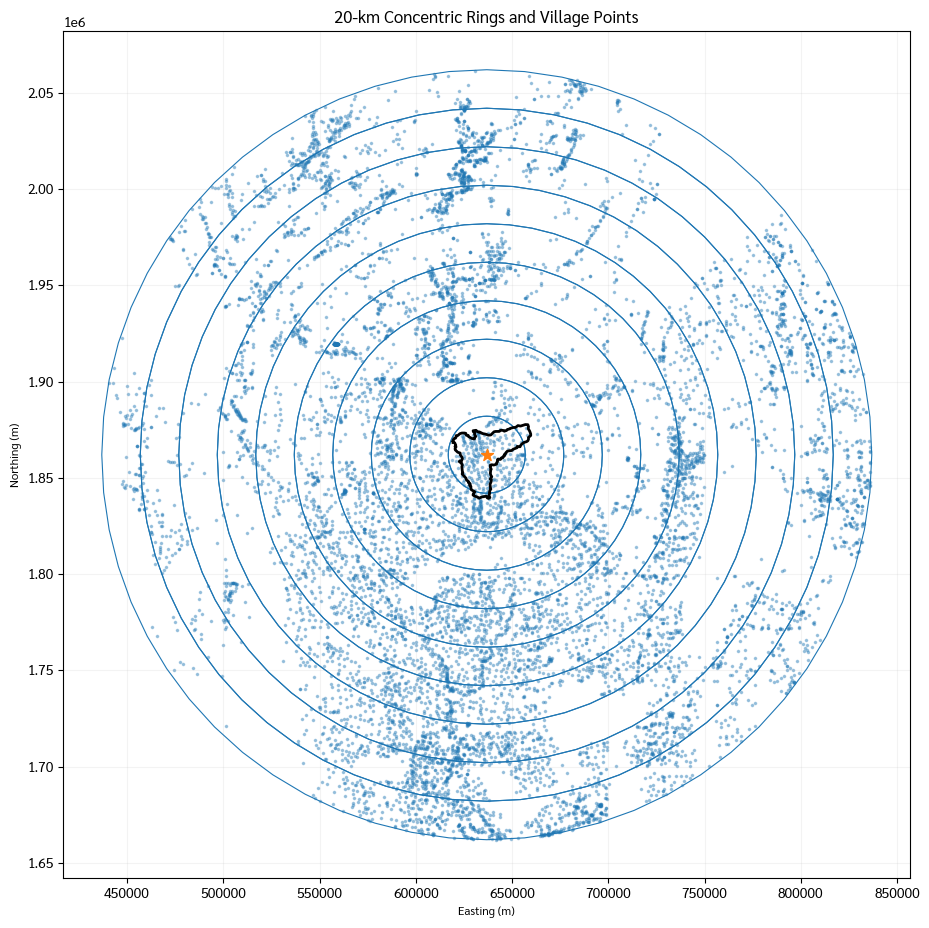

In [34]:
fig_rings, ax = plt.subplots(
    figsize=(11, 11)
)

rings.boundary.plot(
    ax=ax,
    linewidth=0.8
)

village_200.plot(
    ax=ax,
    markersize=2.5,
    alpha=0.35
)

mueang_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=80,
    marker="*"
)

ax.set_title(
    "20-km Concentric Rings and Village Points"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

plt.show()

# Part J — Folium Interactive Distance Map

## 36. Web GIS strategy

ใช้ pattern เดิม:

$$
Full\ GIS
\rightarrow
Compact\ Web\ Layer
\rightarrow
Validated\ GeoJSON
\rightarrow
Folium
$$

แต่ village points ภายใน 200 km อาจมีจำนวนมาก จึงใช้ `FastMarkerCluster`
แทนการสร้าง `CircleMarker` ทีละหลายพันจุด

## 37. JSON-safe helpers

In [35]:
def _json_safe_scalar(value):
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(
        value,
        (str, int, float, bool)
    ):
        return value

    return str(value)


def prepare_web_layer(
    gdf,
    fields,
    numeric_fields=None,
    target_crs="EPSG:4326"
):
    fields = [
        f for f in fields
        if f in gdf.columns
    ]

    fields = list(
        dict.fromkeys(fields)
    )

    web = gdf[
        fields + ["geometry"]
    ].copy()

    web = web.to_crs(
        target_crs
    )

    numeric_fields = (
        numeric_fields or []
    )

    for col in numeric_fields:
        if col in web.columns:
            web[col] = pd.to_numeric(
                web[col],
                errors="coerce"
            ).astype(float)

    for col in fields:
        if col not in numeric_fields:
            web[col] = web[col].map(
                _json_safe_scalar
            )

    return gpd.GeoDataFrame(
        web,
        geometry="geometry",
        crs=target_crs
    )


def to_safe_geojson(gdf):
    obj = json.loads(
        gdf.to_json()
    )

    json.dumps(
        obj,
        ensure_ascii=False
    )

    return obj

## 38. Prepare compact web layers

In [36]:
mueang_web = prepare_web_layer(
    mueang_utm,
    fields=[
        d_adm2_code,
        d_adm1_th,
        d_adm2_th
    ]
)

buffers_web = prepare_web_layer(
    buffers,
    fields=[
        "radius_km"
    ],
    numeric_fields=[
        "radius_km"
    ]
)

rings_web = rings.merge(
    ring_compare[
        [
            "ring_label",
            "village_count_numeric"
        ]
    ],
    on="ring_label",
    how="left"
)

rings_web = prepare_web_layer(
    rings_web,
    fields=[
        "ring_from_km",
        "ring_to_km",
        "ring_label",
        "village_count_numeric"
    ],
    numeric_fields=[
        "ring_from_km",
        "ring_to_km",
        "village_count_numeric"
    ]
)

center_web = gpd.GeoDataFrame(
    {
        "name": [
            "Mueang Phitsanulok geometric centroid"
        ]
    },
    geometry=[
        centroid_geom
    ],
    crs="EPSG:32647"
).to_crs("EPSG:4326")

village_200_web = village_200[
    [
        NAME_FIELD,
        TAMBON_FIELD,
        DISTRICT_FIELD,
        PROVINCE_FIELD,
        "distance_km",
        "geometry"
    ]
].copy().to_crs("EPSG:4326")

## 39. Validate polygon GeoJSON

In [37]:
mueang_geojson = to_safe_geojson(
    mueang_web
)

buffers_geojson = to_safe_geojson(
    buffers_web
)

rings_geojson = to_safe_geojson(
    rings_web
)

for name, obj in [
    ("Mueang", mueang_geojson),
    ("Buffers", buffers_geojson),
    ("Rings", rings_geojson)
]:
    json.dumps(
        obj,
        ensure_ascii=False
    )

    print(
        f"{name}: GeoJSON serialization OK"
    )

Mueang: GeoJSON serialization OK
Buffers: GeoJSON serialization OK
Rings: GeoJSON serialization OK


## 40. Basemap helper

In [38]:
def add_basemap(
    m,
    provider,
    name,
    show=False
):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)

## 41. Create map

In [39]:
center_ll = center_web.geometry.iloc[0]

m = folium.Map(
    location=[
        center_ll.y,
        center_ll.x
    ],
    zoom_start=6,
    tiles=None,
    control_scale=True
)

add_basemap(
    m,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m,
    xyz.Esri.WorldImagery,
    "Esri World Imagery (Satellite)",
    show=False
)

## 42. Mueang polygon + centroid

In [40]:
folium.GeoJson(
    mueang_geojson,
    name="Mueang Phitsanulok",
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "fillOpacity": 0.05,
        "color": "#000000",
        "weight": 2
    }
).add_to(m)

folium.Marker(
    location=[
        center_ll.y,
        center_ll.x
    ],
    tooltip=(
        "Origin: Mueang Phitsanulok geometric centroid"
    )
).add_to(m)

## 43. Cumulative buffer outlines

In [41]:
folium.GeoJson(
    buffers_geojson,
    name="Cumulative buffer outlines",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#444444",
        "weight": 1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "radius_km"
        ],
        aliases=[
            "Radius (km):"
        ]
    )
).add_to(m)

## 44. Concentric rings

In [42]:
folium.GeoJson(
    rings_geojson,
    name="20-km concentric rings",
    show=True,
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "fillOpacity": 0.02,
        "color": "#666666",
        "weight": 1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "ring_label",
            "village_count_numeric"
        ],
        aliases=[
            "Ring:",
            "Village count:"
        ],
        localize=True
    )
).add_to(m)

## 45. FastMarkerCluster — villages within 200 km

In [43]:
cluster_data = [
    [
        geom.y,
        geom.x,
        str(name),
        float(dist)
    ]
    for geom, name, dist in zip(
        village_200_web.geometry,
        village_200_web[NAME_FIELD],
        village_200_web["distance_km"]
    )
]

callback = '''
function (row) {
    var marker = L.circleMarker(
        new L.LatLng(row[0], row[1]),
        {
            radius: 3,
            weight: 1,
            fillOpacity: 0.7
        }
    );

    marker.bindTooltip(
        row[2] + "<br>Distance: "
        + row[3].toFixed(1)
        + " km"
    );

    return marker;
};
'''

FastMarkerCluster(
    data=cluster_data,
    callback=callback,
    name="Village points within 200 km",
    show=True
).add_to(m)

## 46. Layer Control

In [44]:
folium.LayerControl(
    collapsed=False
).add_to(m)

m

# Part K — Publication-quality Figures

## 47. North arrow + scale bar

In [45]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def add_scalebar(
    ax,
    scale_km=50
):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width = xmax - xmin
    height = ymax - ymin

    x0 = xmin + 0.07 * width
    y0 = ymin + 0.05 * height
    x1 = x0 + scale_km * 1000

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.015 * height,
        f"{scale_km} km",
        ha="center",
        fontsize=8
    )

## 48. Publication Map — Centroid

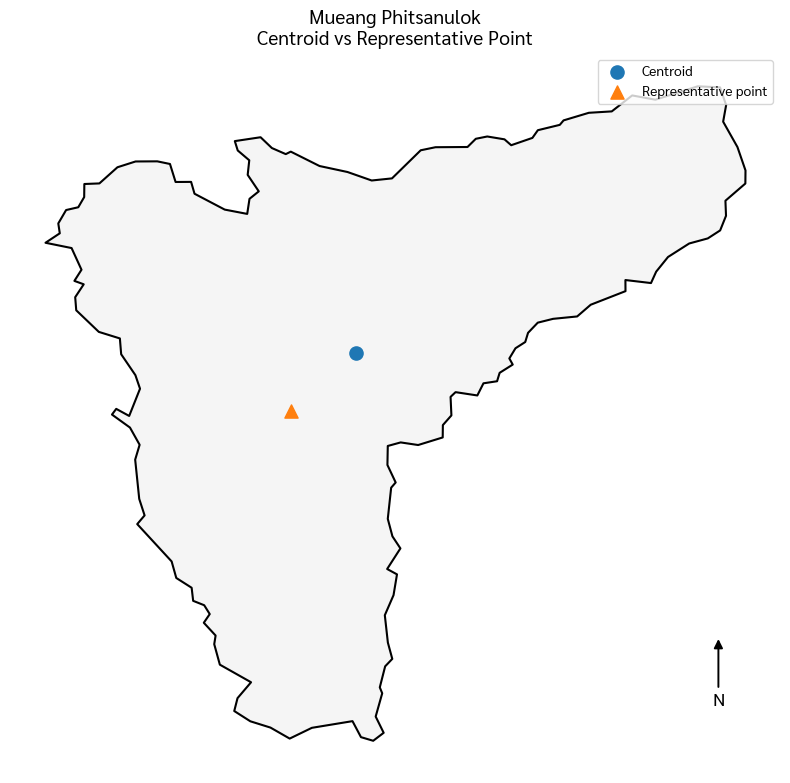

In [46]:
fig_pub_center, ax = plt.subplots(
    figsize=(8, 8)
)

mueang_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=1.5
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=90,
    marker="o",
    label="Centroid"
)

gpd.GeoSeries(
    [repr_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=90,
    marker="^",
    label="Representative point"
)

ax.set_title(
    "Mueang Phitsanulok\n"
    "Centroid vs Representative Point",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
ax.set_axis_off()

add_north_arrow(ax)

plt.tight_layout()
plt.show()

## 49. Publication Map — 20–200 km Buffers

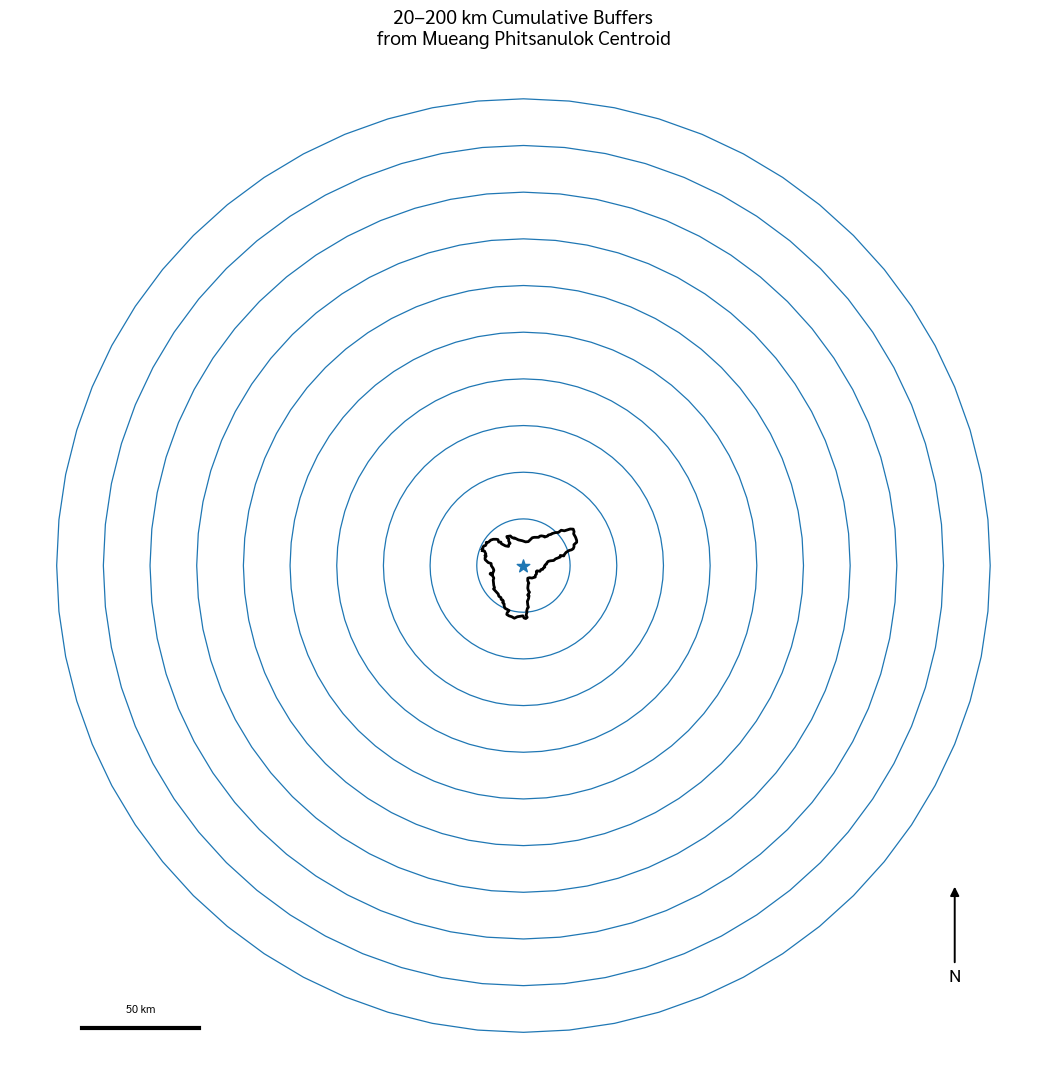

In [47]:
fig_pub_buffers, ax = plt.subplots(
    figsize=(11, 11)
)

buffers.boundary.plot(
    ax=ax,
    linewidth=0.9
)

mueang_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=90,
    marker="*"
)

ax.set_title(
    "20–200 km Cumulative Buffers\n"
    "from Mueang Phitsanulok Centroid",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 50)

plt.tight_layout()
plt.show()

## 50. Publication Map — Concentric Rings + Villages

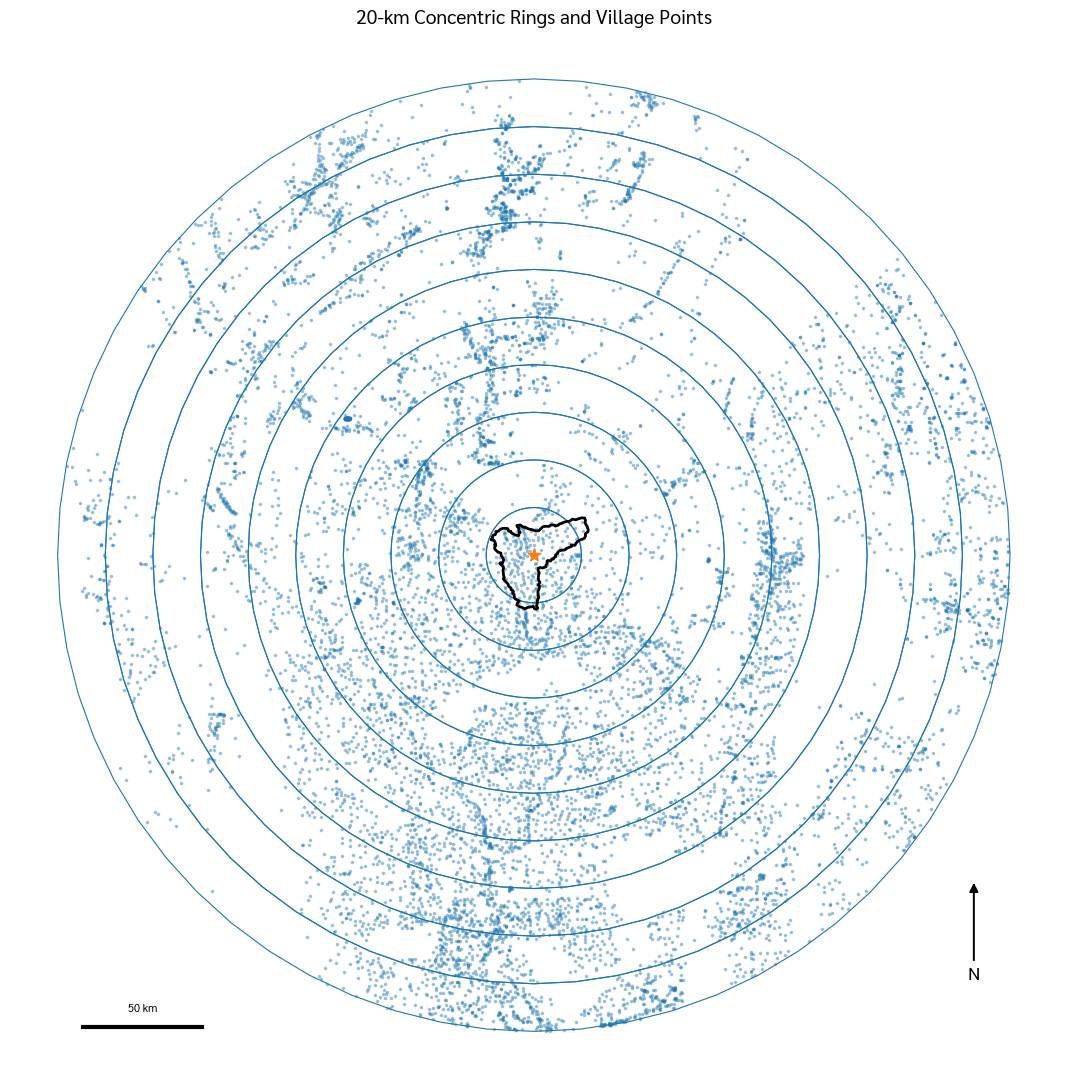

In [48]:
fig_pub_rings, ax = plt.subplots(
    figsize=(11, 11)
)

rings.boundary.plot(
    ax=ax,
    linewidth=0.8
)

village_200.plot(
    ax=ax,
    markersize=2.5,
    alpha=0.35
)

mueang_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gpd.GeoSeries(
    [centroid_geom],
    crs="EPSG:32647"
).plot(
    ax=ax,
    markersize=90,
    marker="*"
)

ax.set_title(
    "20-km Concentric Rings and Village Points",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

add_north_arrow(ax)
add_scalebar(ax, 50)

plt.tight_layout()
plt.show()

# Part L — Export

## 51. Output folders

In [49]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 52. Export PNG 300 dpi

In [50]:
fig_pub_center.savefig(
    MAP_DIR / "mueang_phitsanulok_centroid_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_buffers.savefig(
    MAP_DIR / "village_buffers_20_200km_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_rings.savefig(
    MAP_DIR / "village_concentric_rings_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_cumulative.savefig(
    MAP_DIR / "cumulative_village_count_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_ring_count.savefig(
    MAP_DIR / "village_count_by_ring_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print("PNG figures exported.")

PNG figures exported.


## 53. Export GeoPackage

In [51]:
center_gpkg = (
    VECTOR_DIR
    / "mueang_phitsanulok_center.gpkg"
)

if center_gpkg.exists():
    center_gpkg.unlink()

gpd.GeoDataFrame(
    {
        "center_type": [
            "Geometric centroid"
        ]
    },
    geometry=[
        centroid_geom
    ],
    crs="EPSG:32647"
).to_file(
    center_gpkg,
    layer="center",
    driver="GPKG"
)

buffers_gpkg = (
    VECTOR_DIR
    / "buffers_20_200km.gpkg"
)

if buffers_gpkg.exists():
    buffers_gpkg.unlink()

buffers.to_file(
    buffers_gpkg,
    layer="buffers",
    driver="GPKG"
)

rings_gpkg = (
    VECTOR_DIR
    / "rings_20_200km.gpkg"
)

if rings_gpkg.exists():
    rings_gpkg.unlink()

rings.to_file(
    rings_gpkg,
    layer="rings",
    driver="GPKG"
)

villages_gpkg = (
    VECTOR_DIR
    / "villages_within_200km.gpkg"
)

if villages_gpkg.exists():
    villages_gpkg.unlink()

village_200.to_file(
    villages_gpkg,
    layer="villages_200km",
    driver="GPKG"
)

print("GeoPackages exported.")

GeoPackages exported.


## 54. Export CSV tables

In [52]:
cumulative_df.to_csv(
    TABLE_DIR / "cumulative_village_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

ring_compare.to_csv(
    TABLE_DIR / "village_counts_by_ring.csv",
    index=False,
    encoding="utf-8-sig"
)

village_200[
    [
        NAME_FIELD,
        TAMBON_FIELD,
        DISTRICT_FIELD,
        PROVINCE_FIELD,
        "distance_km",
        "distance_ring"
    ]
].to_csv(
    TABLE_DIR / "villages_within_200km.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV tables exported.")

CSV tables exported.


## 55. Export Folium HTML

In [53]:
html_path = (
    HTML_DIR
    / "village_distance_buffer_interactive.html"
)

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis07_outputs/html/village_distance_buffer_interactive.html


## 56. Inspect outputs

In [54]:
for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(OUTPUT_DIR),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/village_distance_buffer_interactive.html (1,524.7 KB)
maps/cumulative_village_count_300dpi.png (107.5 KB)
maps/mueang_phitsanulok_centroid_300dpi.png (181.7 KB)
maps/village_buffers_20_200km_300dpi.png (703.6 KB)
maps/village_concentric_rings_300dpi.png (1,743.7 KB)
maps/village_count_by_ring_300dpi.png (134.9 KB)
tables/cumulative_village_counts.csv (0.3 KB)
tables/village_counts_by_ring.csv (0.3 KB)
tables/villages_within_200km.csv (1,414.2 KB)
vectors/buffers_20_200km.gpkg (112.0 KB)
vectors/mueang_phitsanulok_center.gpkg (96.0 KB)
vectors/rings_20_200km.gpkg (132.0 KB)
vectors/villages_within_200km.gpkg (2,728.0 KB)


# Concept Check

1. Centroid ต่างจาก representative point อย่างไร?
2. ทำไม centroid ของ polygon ไม่จำเป็นต้องเป็น urban center?
3. ทำไมต้อง reproject ก่อนคำนวณ distance?
4. Euclidean distance ต่างจาก road distance อย่างไร?
5. Buffer ต่างจาก Ring อย่างไร?
6. Cumulative count ต่างจาก ring count อย่างไร?
7. ทำไม outer ring มักมีพื้นที่มากกว่า inner ring?
8. ทำไม raw ring count ยังไม่ใช่ density?
9. ทำไม 200-km study area ไม่เท่ากับ administrative boundary?
10. ทำไม Web GIS ใช้ `FastMarkerCluster` แทนการสร้าง marker หลายพันจุดทีละตัว?

# Exercise 1 — Change the Origin

เปลี่ยน origin จาก

```text
Geometric centroid
```

เป็น

```text
Representative point
```

คำนวณ cumulative counts ใหม่ แล้วเปรียบเทียบว่าแต่ละ radius เปลี่ยนกี่ village points

# Exercise 2 — Change Ring Interval

เปลี่ยน interval จาก

```text
20 km
```

เป็น

```text
25 km
```

จนถึง 200 km

แล้วสร้าง cumulative curve และ ring-count bar chart ใหม่

# Exercise 3 — Nearest Villages

หา 20 village points ที่ใกล้ origin ที่สุด

สร้างตาราง:

```text
Rank
Village
Tambon
District
Province
Distance km
```

# Exercise 4 — Compare Cumulative vs Ring Count

อธิบายความต่างระหว่าง:

```text
N(≤ 100 km)
```

กับ

```text
N(80–100 km)
```

และอธิบายว่าทำไมค่าทั้งสองตอบคนละคำถาม

# Exercise 5 — Visual Interpretation with Esri World Imagery

ใน Folium เปิด:

```text
Esri World Imagery
+
20-km rings
+
Village points
```

เปรียบเทียบ settlement pattern อย่างน้อย 3 zones:

```text
0–20 km
80–100 km
180–200 km
```

อธิบายเชิงคุณภาพว่าภูมิประเทศหรือ land-cover context อาจสัมพันธ์กับ village distribution อย่างไร

# MSc Challenge — Origin Sensitivity

เปรียบเทียบ origin 3 แบบ:

```text
1. Geometric centroid
2. Representative point
3. จุดศูนย์กลางเมืองที่เลือกเอง
```

คำนวณ

$$
N(\le20),N(\le40),...,N(\le200)
$$

ของทั้งสาม origin

แล้วอภิปรายว่า

> radial analysis มี sensitivity ต่อการเลือก origin มากเพียงใด?

นี่เป็นตัวอย่างสำคัญของ **analysis-design sensitivity**

# Summary

Notebook 07 เพิ่ม proximity analysis ให้กับ workflow GIS

$$
\boxed{
Center
\rightarrow
Distance
\rightarrow
Buffer
\rightarrow
Ring
\rightarrow
Count
\rightarrow
Spatial\ Pattern
}
$$

สิ่งที่ต้องจำ:

> **Geometric centroid ≠ Urban center**

> **Euclidean distance ≠ Road distance ≠ Travel time**

> **Buffer ≠ Ring**

> **Ring count ≠ Ring density**

> **Distance-defined study area ≠ Administrative boundary**

## ต่อไป: Notebook 08

**Clip, Intersection, Overlay, Dissolve & Introductory Spatial Statistics**

คำถามเปิดบท:

> ถ้า concentric rings บางส่วนอยู่นอกประเทศไทย เราจะ clip rings ให้เหลือเฉพาะพื้นที่ประเทศไทย แล้วคำนวณ effective ring area และ village density อย่างถูกต้องได้อย่างไร?